# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

## Library & Load Dataset

library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# pertama kali saja:

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# digunakan di preprocessing
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [3]:
# Load Dataset
df_raw = pd.read_csv('games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


>Penjelasan singkat: Membaca dataset `games_fixed.csv` yang merupakan dataset dari kaggle 

Exploratory Data Analysis (EDA)

In [4]:
# Exploratory Data Analysis (EDA)

df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre_raw'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre_raw
15288,Death Rattle - Hell Unleashed,You are the Death Rattle - humanity's last hop...,"['Action', 'Adventure', 'Indie', 'RPG']"
36144,Barbaria,Barbaria is a VR combat/builder mashup. Attack...,"['Action', 'Indie', 'RPG', 'Strategy']"
17364,SYNTHETIK 2,Fight as part of the human defiance against th...,"['Action', 'Indie', 'Early Access']"
53344,The Customer is Always Right!,"It's your first day at the job, just like any ...","['Action', 'Adventure', 'Indie', 'RPG', 'Simul..."
111496,Deep Sky Derelicts,"In a grim dystopian future, where mankind has ...","['Indie', 'RPG', 'Strategy']"


Cek missing values

In [5]:
# Cek missing values
df.isna().sum()

title           1
synopsis     8448
genre_raw       0
dtype: int64

Hapus baris yang tidak punya sinopsis atau genre

In [6]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre_raw']).reset_index(drop=True)

# Tambahan: hapus genre yang kosong secara konten, seperti [], [''], dll.
df['genre_raw'] = df['genre_raw'].astype(str).str.strip()

# Filter keluar string yang merepresentasikan list kosong
df = df[~df['genre_raw'].isin(['[]', "['']", '[""]', '', 'nan'])].reset_index(drop=True)

print("Jumlah data setelah drop NA dan genre kosong:", df.shape)

Jumlah data setelah drop NA dan genre kosong: (114022, 3)


In [7]:
df.sample(5)

,title,synopsis,genre_raw
98500,The Curse Of Yendor,WHAT: A sword and sorcery adventure where your...,"['Action', 'Adventure', 'Indie', 'RPG', 'Strat..."
4430,Hover Tank Arena,Hover Tank Arena combat is a single-player gam...,"['Action', 'Indie', 'Sports', 'Early Access']"
17,Battle Motion,Single-player action game with massive fantasy...,"['Action', 'Indie', 'RPG', 'Simulation', 'Earl..."
21657,BONELAB,"BONELAB Sentenced to death, you embody an outc...","['Action', 'Adventure', 'Simulation']"
79691,Flat 9,"Sent to investigate an abandoned apartment, yo...","['Adventure', 'Indie', 'Simulation']"


## Normalisasi Genre

In [8]:
# Genre target: 4 genre gameplay murni (tanpa 'indie' & 'casual')
target_genres = {'action', 'adventure', 'rpg', 'simulation'}

def parse_genre_list(genre_str):
    """
    Parse string genre seperti "['Action', 'Indie']" menjadi list python ['action', 'indie'].
    Tidak melakukan penghapusan manual karakter [ ] dengan replace,
    melainkan parsing aman menggunakan ast.literal_eval.
    """
    if pd.isna(genre_str):
        return []
    
    # Jika sudah list, kembalikan langsung
    if isinstance(genre_str, list):
        raw_list = genre_str
    else:
        text = str(genre_str).strip()
        try:
            # Coba parse sebagai literal Python
            raw_list = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # Jika gagal, fallback split sederhana dengan koma
            raw_list = [g.strip() for g in text.split(',')]
    
    # Normalisasi ke huruf kecil tanpa spasi ekstra
    cleaned = [g.strip().lower() for g in raw_list if isinstance(g, str)]
    return cleaned

# Terapkan parsing ke seluruh kolom genre_raw
df['genre_list'] = df['genre_raw'].apply(parse_genre_list)

# Ambil hanya genre yang termasuk subset target
df['genre_filtered'] = df['genre_list'].apply(
    lambda lst: [g for g in lst if g in target_genres]
)

# Hitung panjang list hasil filter
df['genre_count'] = df['genre_filtered'].apply(len)

print("Distribusi jumlah genre target per game:")
print(df['genre_count'].value_counts().sort_index())

Distribusi jumlah genre target per game:
genre_count
0    25759
1    51293
2    27328
3     8309
4     1333
Name: count, dtype: int64


In [9]:
df.sample(5)

,title,synopsis,genre_raw,genre_list,genre_filtered,genre_count
27463,Path of the Abyss,"Path of the Abyss is a single-player, grid-bas...",['RPG'],[rpg],[rpg],1
62701,Dungeons and Ducklings,"~ Baby ducklings have been kidnapped, and you ...","['Action', 'Indie']","[action, indie]",[action],1
45464,Bent Oak Island,What People Think About The Game: 'What makes ...,['Adventure'],[adventure],[adventure],1
45094,The Last Team 最后的小队,Game Introduction 9 heroes with different styl...,"['Indie', 'RPG', 'Strategy']","[indie, rpg, strategy]",[rpg],1
107157,RoboWorlD tactics,The game is in the style of RTS (real-time str...,"['Action', 'Indie', 'Simulation', 'Strategy']","[action, indie, simulation, strategy]","[action, simulation]",2


In [10]:
# Untuk menjaga single-label classification sesuai proposal,
# hanya ambil data yang memiliki tepat satu genre target
df_single = df[df['genre_count'] == 1].copy().reset_index(drop=True)

# Ambil genre utama
df_single['genre_main'] = df_single['genre_filtered'].str[0]

print("Jumlah data setelah filter subset genre dan single-label:", df_single.shape)
df_single[['title','synopsis' , 'genre_raw', 'genre_list', 'genre_filtered', 'genre_main']].head(10)

Jumlah data setelah filter subset genre dan single-label: (51293, 7)


,title,synopsis,genre_raw,genre_list,genre_filtered,genre_main
0,Counter-Strike,Play the world's number 1 online action game. ...,['Action'],[action],[action],action
1,Counter-Strike: Condition Zero,"With its extensive Tour of Duty campaign, a ne...",['Action'],[action],[action],action
2,Tower of Origin2-Worm's Nest,"If you want to talk to me , please follow this...","['Indie', 'RPG']","[indie, rpg]",[rpg],rpg
3,Hellish Quart,Hellish Quart is a local-only (two players pla...,"['Action', 'Early Access']","[action, early access]",[action],action
4,WRATH: Aeon of Ruin,You are Outlander. Once adrift upon the Ageles...,['Action'],[action],[action],action
5,东方雪莲华 ～ Abyss Soul Lotus.,东方雪莲华 ～ Abyss Soul Lotus.是在东方Project世界观基础上创作的二...,"['Action', 'Indie']","[action, indie]",[action],action
6,The Undisputables : Online Multiplayer Shooter,The Undisputables : Online Multiplayer is a co...,"['Action', 'Indie', 'Massively Multiplayer']","[action, indie, massively multiplayer]",[action],action
7,Clam Man,Disclaimer! Clam Man is a game built around jo...,"['Adventure', 'Indie']","[adventure, indie]",[adventure],adventure
8,Insomnis,The old Castevet manor has just been uninhabit...,"['Adventure', 'Indie']","[adventure, indie]",[adventure],adventure
9,Flex Apocalypse Racing,An apocalypse has happened. Much has changed i...,"['Indie', 'Racing', 'Simulation', 'Sports']","[indie, racing, simulation, sports]",[simulation],simulation


sebaran genre

In [11]:
df_single['genre_main'].value_counts()

genre_main
action        20029
adventure     14925
simulation    11454
rpg            4885
Name: count, dtype: int64

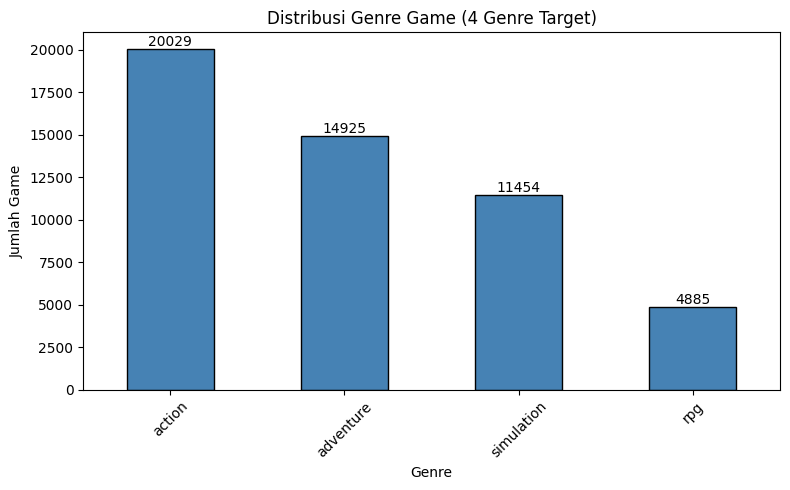

In [12]:
# Visualisasi distribusi genre (single-label, 4 genre target)
genre_counts = df_single['genre_main'].value_counts()

plt.figure(figsize=(8, 5))
ax = genre_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Genre Game (4 Genre Target)')
plt.xlabel('Genre')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Filter Bahasa Inggris & Text Cleaning

In [13]:
# TEXT CLEANING & LANGUAGE FILTERING (ENGLISH-ONLY)
def basic_english_filter(text):
    
    # Filter sederhana untuk memastikan sinopsis dominan karakter Latin dan tidak terlalu pendek.
   
    if not isinstance(text, str):
        return False
    
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    
    if len(clean.split()) < 3:
        return False
    
    ratio = len(clean) / max(len(text), 1)
    return ratio >= 0.7

df_single['is_english'] = df_single['synopsis'].apply(basic_english_filter)
print(df_single['is_english'].value_counts())

df_single = df_single[df_single['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df_single.shape)

is_english
True     50378
False      915
Name: count, dtype: int64
Jumlah data setelah filter bahasa Inggris: (50378, 7)


## Penghapusan Sinopsis Terlalu Pendek

In [14]:
# Parameter ambang 
MIN_WORDS = 10    # minimal 10 kata bermakna untuk dapat menebak genre
MIN_CHARS = 40    # minimal 40 karakter

df_single['word_count'] = df_single['synopsis'].apply(lambda x: len(str(x).split()))
df_single['char_count'] = df_single['synopsis'].apply(lambda x: len(str(x).strip()))

print("Statistik panjang sinopsis (kata):")
print(df_single['word_count'].describe())

Statistik panjang sinopsis (kata):
count    50378.000000
mean       217.279507
std        157.930625
min          3.000000
25%        119.000000
50%        181.000000
75%        270.000000
max       8402.000000
Name: word_count, dtype: float64


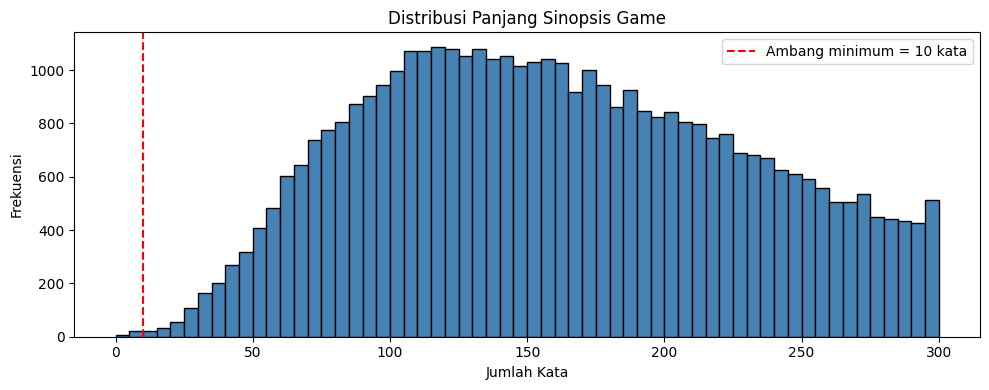

In [15]:
# Visualisasi distribusi panjang sinopsis + ambang minimum absolut
plt.figure(figsize=(10, 4))
plt.hist(df_single['word_count'], bins=60, range=(0, 300), color='steelblue', edgecolor='black')
plt.axvline(MIN_WORDS, color='red', linestyle='--', label=f'Ambang minimum = {MIN_WORDS} kata')
plt.xlabel('Jumlah Kata'); plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sinopsis Game')
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
# Terapkan tiga kriteria penyaringan
_syn = df_single['synopsis'].astype(str).str.strip()

# 1) Teks placeholder / tidak informatif
placeholder_re = re.compile(r'^(no description( available)?|coming soon|tba|tbd|n/?a|none|\.+|-+)$', re.I)
is_placeholder = _syn.apply(lambda s: bool(placeholder_re.match(s)))

# 2) Terlalu pendek (jumlah kata ATAU karakter di bawah ambang)
too_short = (df_single['word_count'] < MIN_WORDS) | (df_single['char_count'] < MIN_CHARS)

# 3) Sinopsis duplikat (boilerplate copy-paste antar game)
is_dup = _syn.str.lower().duplicated(keep='first')

remove_mask = is_placeholder | too_short | is_dup
before = len(df_single)
print(f"Placeholder / tidak informatif         : {int(is_placeholder.sum())}")
print(f"Terlalu pendek (<{MIN_WORDS} kata / <{MIN_CHARS} char) : {int(too_short.sum())}")
print(f"Sinopsis duplikat                      : {int(is_dup.sum())}")
print(f"Total baris dibuang (gabungan)         : {int(remove_mask.sum())}")

df_single = df_single[~remove_mask].drop(columns=['word_count', 'char_count']).reset_index(drop=True)
after = len(df_single)
print(f"\nData sebelum : {before}")
print(f"Data sesudah : {after}  (dibuang {before - after}, {(before - after) / before * 100:.2f}%)")

Placeholder / tidak informatif         : 0
Terlalu pendek (<10 kata / <40 char) : 25
Sinopsis duplikat                      : 91
Total baris dibuang (gabungan)         : 116

Data sebelum : 50378
Data sesudah : 50262  (dibuang 116, 0.23%)


## PRE-Prosessing


preprocessing mencakup case folding, tokenizing, stopword removal, dan stemming, dan batasan masalah perubahan kombinasi fitur preprocessing.

Skenario:

- S1: Case folding + tokenizing + stopword removal

- S2: Case folding + tokenizing + stemming

- S3: Case folding + tokenizing + stopword removal + stemming

In [17]:
# TEXT PREPROCESSING SCENARIOS

def case_folding(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in english_stopwords]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess(text, use_stopword=True, use_stemming=True):
    text = case_folding(text)
    tokens = tokenize(text)
    if use_stopword:
        tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Skenario 1: stopword removal tanpa stemming
df_single['synopsis_S1'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=False)
)

# Skenario 2: stemming tanpa stopword removal
df_single['synopsis_S2'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=False, use_stemming=True)
)

# Skenario 3: stopword removal + stemming
df_single['synopsis_S3'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=True)
)

df_single[['title', 'genre_main', 'synopsis', 'synopsis_S3']].head(5)

,title,genre_main,synopsis,synopsis_S3
0,Counter-Strike,action,Play the world's number 1 online action game. ...,play world number onlin action game engag incr...
1,Counter-Strike: Condition Zero,action,"With its extensive Tour of Duty campaign, a ne...",extens tour duti campaign near limitless numbe...
2,Tower of Origin2-Worm's Nest,rpg,"If you want to talk to me , please follow this...",want talk pleas follow twitter made frankli ma...
3,Hellish Quart,action,Hellish Quart is a local-only (two players pla...,hellish quart local two player play one pc onl...
4,WRATH: Aeon of Ruin,action,You are Outlander. Once adrift upon the Ageles...,outland adrift upon ageless sea find shore die...


Feature Extraction dengan TF‑IDF

In [18]:
# Feature Extraction dengan TF‑IDF
TEXT_COL = 'synopsis_S3'

X_text = df_single[TEXT_COL]
y = df_single['genre_main']

print("Contoh teks setelah preprocessing:")
print(X_text.iloc[0])
print("Label genre:", y.iloc[0])

Contoh teks setelah preprocessing:
play world number onlin action game engag incred realist brand terrorist warfar wildli popular team base game alli teammat complet strateg mission take enemi site rescu hostag role affect team success team success affect role
Label genre: action


spliting data

In [19]:
# Train test split dengan stratified sesuai genre
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data train:", X_train_text.shape[0])
print("Jumlah data test :", X_test_text.shape[0])

Jumlah data train: 40209
Jumlah data test : 10053


In [20]:
# TF-IDF: fit hanya pada data train
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

X_train.shape, X_test.shape

((40209, 20000), (10053, 20000))

## Modeling & Training

Spliting model sebelum train spliting data menjadi 80 20


`test_size=0.2` 20% data untuk test

Sisanya 80% untuk model train

Model Naive Bayes

In [21]:
# NAIVE BAYES

nb_clf = MultinomialNB(alpha=0.1)
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)

Model K-Nearest Neighbors

In [22]:
# K-NEAREST NEIGHBORS

knn_clf = KNeighborsClassifier(n_neighbors=11, metric='cosine')
knn_clf.fit(X_train, y_train)

y_pred_knn = knn_clf.predict(X_test)

Model Support Vector Machine

In [23]:
# SUPPORT VECTOR MACHINE 

svm_clf = LinearSVC(class_weight='balanced', max_iter=5000)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

## Evaluasi Model


In [24]:
# FUNGSI BANTU EVALUASI

def evaluate_model(y_true, y_pred, model_name):
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)
    
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

MODEL: Naive Bayes
              precision    recall  f1-score   support

      action       0.81      0.87      0.84      3973
   adventure       0.74      0.80      0.77      2911
         rpg       0.71      0.56      0.63       913
  simulation       0.82      0.70      0.75      2256

    accuracy                           0.78     10053
   macro avg       0.77      0.73      0.75     10053
weighted avg       0.78      0.78      0.78     10053



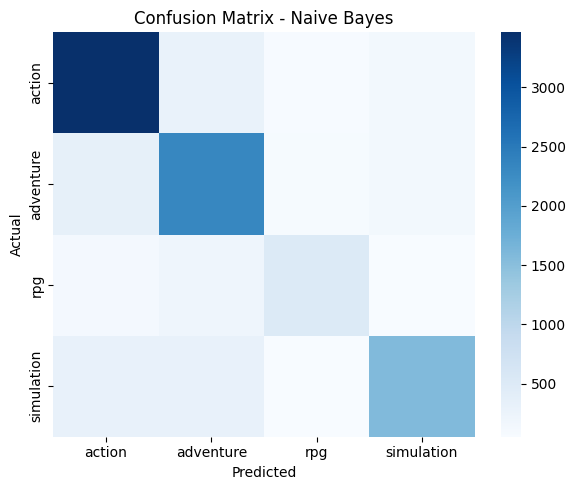

MODEL: K-Nearest Neighbors
              precision    recall  f1-score   support

      action       0.78      0.85      0.81      3973
   adventure       0.74      0.74      0.74      2911
         rpg       0.74      0.51      0.61       913
  simulation       0.75      0.73      0.74      2256

    accuracy                           0.76     10053
   macro avg       0.75      0.71      0.72     10053
weighted avg       0.76      0.76      0.76     10053



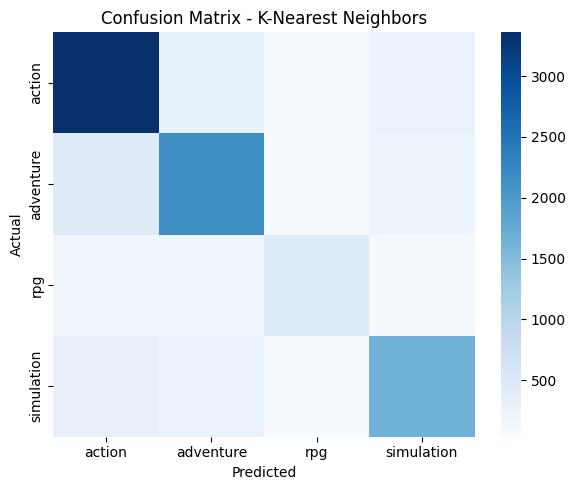

MODEL: Support Vector Machine
              precision    recall  f1-score   support

      action       0.85      0.85      0.85      3973
   adventure       0.77      0.78      0.77      2911
         rpg       0.68      0.68      0.68       913
  simulation       0.79      0.77      0.78      2256

    accuracy                           0.80     10053
   macro avg       0.77      0.77      0.77     10053
weighted avg       0.80      0.80      0.80     10053



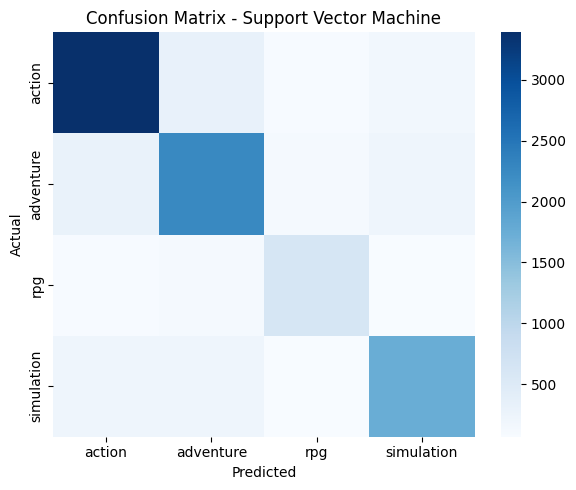

In [25]:
# EVALUASI KETIGA MODEL

evaluate_model(y_test, y_pred_nb,  'Naive Bayes')
evaluate_model(y_test, y_pred_knn, 'K-Nearest Neighbors')
evaluate_model(y_test, y_pred_svm, 'Support Vector Machine')

## Validasi Silang K-Fold (Stratified, k=5)


In [26]:
# VALIDASI SILANG K-FOLD (Stratified, k=5) untuk estimasi performa yang lebih stabil.
# Metrik sesuai proposal: Accuracy, Precision, Recall, F1-Score (macro average).
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

TEXT_COL_CV = 'synopsis_S3'   # skenario stopword removal + stemming
X_cv = df_single[TEXT_COL_CV]
y_cv = df_single['genre_main']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Stratified agar proporsi tiap genre terjaga di setiap fold
scoring = {
    'Accuracy':  'accuracy',
    'Precision': 'precision_macro',
    'Recall':    'recall_macro',
    'F1-Score':  'f1_macro',
}

cv_models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'KNN (k=11)':  KNeighborsClassifier(n_neighbors=11, metric='cosine'),
    'Linear SVM':  LinearSVC(class_weight='balanced', max_iter=5000),
}

cv_rows = []
for name, model in cv_models.items():
    # TF-IDF di-fit ulang di tiap fold (lewat Pipeline) agar tidak ada kebocoran data
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)),
        ('clf', model),
    ])
    scores = cross_validate(pipe, X_cv, y_cv, cv=skf, scoring=scoring)
    row = {'Model': name}
    for label in scoring:
        m = scores[f'test_{label}'].mean()
        s = scores[f'test_{label}'].std()
        row[label] = f"{m*100:.2f}% ± {s*100:.2f}%"
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows)
print("Hasil 5-Fold Stratified Cross Validation (skenario S3) - rata-rata ± std antar fold")
cv_df


Hasil 5-Fold Stratified Cross Validation (skenario S3) - rata-rata ± std antar fold


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,78.35% ± 0.48%,77.36% ± 0.48%,73.40% ± 0.76%,74.95% ± 0.67%
1,KNN (k=11),75.93% ± 0.38%,75.28% ± 0.47%,70.67% ± 0.54%,72.36% ± 0.50%
2,Linear SVM,79.58% ± 0.18%,77.13% ± 0.38%,76.92% ± 0.55%,77.01% ± 0.45%


### Tabel MSE & RMSE


In [27]:
# TABEL MSE & RMSE PER MODEL (Skenario utama / S3)
# Catatan: genre adalah label kategorikal, sehingga di-encode ke angka
# dengan LabelEncoder terlebih dahulu sebelum menghitung MSE & RMSE.
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

# Encoder dilatih pada seluruh kelas genre agar konsisten
le = LabelEncoder()
le.fit(df_single['genre_main'])

def hitung_mse_rmse(y_true, y_pred):
    yt = le.transform(y_true)
    yp = le.transform(y_pred)
    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    return mse, rmse

mse_rows = []
for model_name, y_pred in [
    ('Naive Bayes', y_pred_nb),
    ('KNN (k=11)', y_pred_knn),
    ('Linear SVM', y_pred_svm),
]:
    mse, rmse = hitung_mse_rmse(y_test, y_pred)
    mse_rows.append({'Model': model_name, 'MSE': mse, 'RMSE': rmse})

# Urutkan dari MSE terkecil (error terkecil = terbaik)
mse_df = pd.DataFrame(mse_rows).sort_values('MSE').reset_index(drop=True)

mse_display = mse_df.copy()
mse_display['MSE'] = mse_display['MSE'].apply(lambda x: f"{x:.4f}")
mse_display['RMSE'] = mse_display['RMSE'].apply(lambda x: f"{x:.4f}")

print("Tabel MSE & RMSE per Model (Skenario S3, diurutkan dari MSE terkecil)")
mse_display


Tabel MSE & RMSE per Model (Skenario S3, diurutkan dari MSE terkecil)


,Model,MSE,RMSE
0,Linear SVM,0.7000,0.8367
1,Naive Bayes,0.7779,0.8820
2,KNN (k=11),0.9022,0.9499


In [28]:
# PERBANDINGAN PERFORMA ANTAR SKENARIO PREPROCESSING (S1, S2, S3)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

scenarios = {
    'S1_stopword_only': 'synopsis_S1',
    'S2_stemming_only': 'synopsis_S2',
    'S3_stopword_stem': 'synopsis_S3'
}

# Encoder genre -> angka (untuk MSE & RMSE), dilatih pada seluruh kelas
le_cmp = LabelEncoder()
le_cmp.fit(df_single['genre_main'])

results = []

for scen_name, text_col in scenarios.items():
    print(f"SKENARIO: {scen_name}  (kolom: {text_col})")
    
    # 1) Ambil teks dan label
    X_text = df_single[text_col]
    y = df_single['genre_main']
    
    # 2) Train-test split (stratified)
    X_train_text, X_test_text, y_train_s, y_test_s = train_test_split(
        X_text, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3) TF-IDF khusus skenario ini
    tfidf_s = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=3,
        max_df=0.95
    )
    X_train_s = tfidf_s.fit_transform(X_train_text)
    X_test_s  = tfidf_s.transform(X_test_text)
    
    # 4) Definisi model-model
    models = {
        'Naive Bayes': MultinomialNB(alpha=0.1),
        'KNN (k=11)': KNeighborsClassifier(n_neighbors=11, metric='cosine'),
        'Linear SVM': LinearSVC(class_weight='balanced', max_iter=5000)
    }
    
    # 5) Training, prediksi, dan simpan metrik
    for model_name, model in models.items():
        model.fit(X_train_s, y_train_s)
        y_pred_s = model.predict(X_test_s)
        
        acc  = accuracy_score(y_test_s, y_pred_s)
        prec = precision_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        rec  = recall_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        f1   = f1_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        
        # MSE & RMSE (label di-encode ke angka lebih dulu)
        yt = le_cmp.transform(y_test_s)
        yp = le_cmp.transform(y_pred_s)
        mse  = mean_squared_error(yt, yp)
        rmse = np.sqrt(mse)
        
        results.append({
            'Scenario': scen_name,
            'Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'MSE': mse,
            'RMSE': rmse
        })

# 6) Tabel ringkasan
results_df = pd.DataFrame(results)

# Urutkan dari F1 tertinggi ke terendah
results_df = results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)

# Format tampilan untuk penulisan tesis
results_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    results_display[col] = results_display[col].apply(lambda x: f"{x * 100:.2f}%")
for col in ['MSE', 'RMSE']:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}")

results_display.columns = ['Scenario', 'Model', 'Accuracy (%)', 'Precision (%)',
                           'Recall (%)', 'F1-Score (%)', 'MSE', 'RMSE']

print("Tabel Perbandingan Performa Antar Skenario Preprocessing dan Model")
results_display


SKENARIO: S1_stopword_only  (kolom: synopsis_S1)
SKENARIO: S2_stemming_only  (kolom: synopsis_S2)
SKENARIO: S3_stopword_stem  (kolom: synopsis_S3)
Tabel Perbandingan Performa Antar Skenario Preprocessing dan Model


,Scenario,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),MSE,RMSE
0,S3_stopword_stem,Linear SVM,79.68%,77.19%,76.97%,77.07%,0.7000,0.8367
1,S2_stemming_only,Linear SVM,79.59%,77.15%,76.76%,76.95%,0.7290,0.8538
2,S1_stopword_only,Linear SVM,79.55%,77.13%,76.72%,76.92%,0.7114,0.8435
3,S1_stopword_only,Naive Bayes,78.42%,77.34%,73.39%,74.96%,0.7698,0.8774
4,S3_stopword_stem,Naive Bayes,78.36%,77.07%,73.21%,74.73%,0.7779,0.8820
5,S2_stemming_only,Naive Bayes,77.74%,76.77%,72.32%,74.01%,0.8103,0.9002
6,S2_stemming_only,KNN (k=11),76.40%,75.45%,70.75%,72.51%,0.8560,0.9252
7,S3_stopword_stem,KNN (k=11),75.93%,75.29%,70.72%,72.43%,0.9022,0.9499
8,S1_stopword_only,KNN (k=11),75.99%,75.73%,70.46%,72.38%,0.9114,0.9547


## Tabel Perbandingan Akhir (Lengkap)

In [29]:
# TABEL PERBANDINGAN AKHIR (LENGKAP): seluruh metrik evaluasi + MSE & RMSE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Encode label genre -> angka untuk perhitungan MSE & RMSE
le_final   = LabelEncoder().fit(df_single['genre_main'])
y_test_enc = le_final.transform(y_test)

preds = {
    'Naive Bayes': y_pred_nb,
    'KNN (k=11)':  y_pred_knn,
    'Linear SVM':  y_pred_svm,
}

final_rows = []
for name, y_pred in preds.items():
    mse = mean_squared_error(y_test_enc, le_final.transform(y_pred))
    final_rows.append({
        'Model':         name,
        'Accuracy (%)':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'Recall (%)':    round(recall_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'F1-Score (%)':  round(f1_score(y_test, y_pred, average='macro', zero_division=0) * 100, 2),
        'MSE':           round(mse, 4),
        'RMSE':          round(np.sqrt(mse), 4),
    })

final_comparison_df = (pd.DataFrame(final_rows)
                         .sort_values('F1-Score (%)', ascending=False)
                         .reset_index(drop=True))
print("Tabel Perbandingan Akhir (Lengkap) - Metrik Evaluasi + MSE & RMSE")
final_comparison_df


Tabel Perbandingan Akhir (Lengkap) - Metrik Evaluasi + MSE & RMSE


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),MSE,RMSE
0,Linear SVM,79.68,77.19,76.97,77.07,0.7000,0.8367
1,Naive Bayes,78.36,77.07,73.21,74.73,0.7779,0.8820
2,KNN (k=11),75.93,75.29,70.72,72.43,0.9022,0.9499


## Implementasi

In [30]:
# IMPLEMENTASI: KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
# Otomatis memakai model dengan F1 tertinggi dari tabel perbandingan.

best  = results_df.sort_values('F1', ascending=False).iloc[0]
_prep = {'S1_stopword_only': (True, False), 'S2_stemming_only': (False, True),
         'S3_stopword_stem': (True, True)}[best['Scenario']]

final_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)
final_model = {'Naive Bayes': MultinomialNB(alpha=0.1),
               'KNN (k=11)':  KNeighborsClassifier(n_neighbors=11, metric='cosine'),
               'Linear SVM':  LinearSVC(class_weight='balanced', max_iter=5000)}[best['Model']]
final_model.fit(final_tfidf.fit_transform(df_single[scenarios[best['Scenario']]]), df_single['genre_main'])

def predict_genre(text):
    return final_model.predict(final_tfidf.transform([preprocess(text, *_prep)]))[0]

def predict_genre_ranked(text, top_n=3):
    vec = final_tfidf.transform([preprocess(text, *_prep)])
    classes = final_model.classes_
    if hasattr(final_model, "predict_proba"):
        scores = np.asarray(final_model.predict_proba(vec))[0]
    else:
        # LinearSVC: decision_function -> keyakinan via softmax
        d = np.atleast_1d(final_model.decision_function(vec)[0])
        e = np.exp(d - np.max(d))
        scores = e / e.sum()
    order = np.argsort(scores)[::-1][:top_n]
    return [(classes[i], float(scores[i])) for i in order]

# Contoh inferensi
contoh = "An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters."
print(f"Model terbaik  : {best['Model']} ({best['Scenario']}, F1={best['F1']*100:.2f}%)")
print(f"Sinopsis       : {contoh}")
pred = predict_genre(contoh)
print(f"Prediksi genre : {pred}")
print("\nSkor keyakinan per genre (Top-5):")
for genre, p in predict_genre_ranked(contoh, top_n=5):
    tanda = "  <-- terprediksi" if genre == pred else ""
    print(f"  {genre:<12}: {p*100:5.1f}%{tanda}")


Model terbaik  : Linear SVM (S3_stopword_stem, F1=77.07%)
Sinopsis       : An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters.
Prediksi genre : adventure

Skor keyakinan per genre (Top-5):
  adventure   :  43.1%  <-- terprediksi
  rpg         :  39.0%
  action      :   9.2%
  simulation  :   8.7%
